In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import scipy


plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'

In [2]:
dir = '/Users/mleclair/phd/code/dunex/data/argus'
file = 'ArgusFF_20211013T170100Z_RectifiedVideo.avi'
os.path.join(dir, file) 

'/Users/mleclair/phd/code/dunex/data/argus/ArgusFF_20211013T170100Z_RectifiedVideo.avi'

In [68]:
# Create Timestacks for each cross-shore location
cap = cv2.VideoCapture(os.path.join(dir, file))
N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'{np.zeros((N, W), dtype=np.uint8).nbytes/1000/1000}mb per timestack')

# NOTE: We're downsampling in along-shore to 10m
skip = 160
timestack = np.zeros((N, H//skip, W))


for i in tqdm(range(N)):
    _, frame = cap.read()
    timestack[i] = frame[::skip, :, 0]

cap.release()
cv2.destroyAllWindows()

1.92mb per timestack


  0%|          | 0/3840 [00:00<?, ?it/s]

100%|██████████| 3840/3840 [00:03<00:00, 1213.94it/s]


100%|██████████| 10/10 [00:00<00:00, 18.98it/s]


(300.0, 600.0)

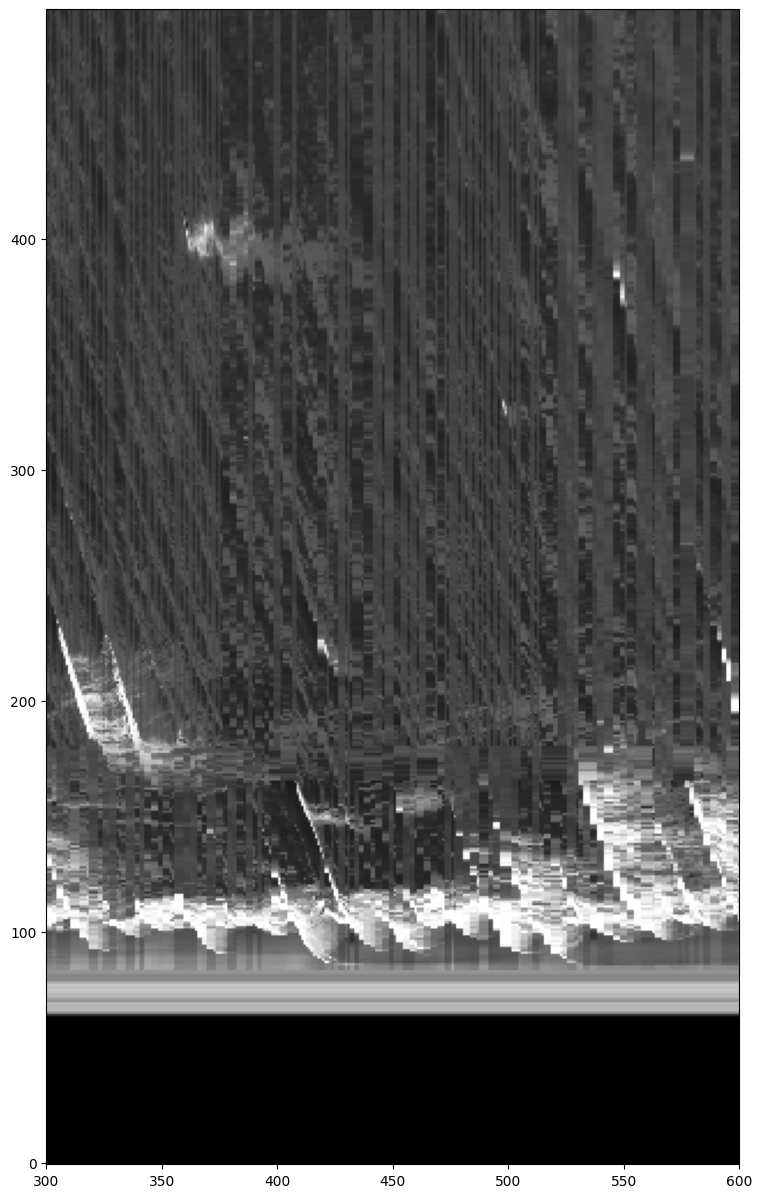

In [66]:
# Forward Fill Missing Data
for c in tqdm(range(timestack.shape[1])):
    tt = timestack[:, c, :].T
    tt[tt==0] = np.nan
    extend = 20
    mask = scipy.ndimage.binary_dilation(np.isnan(tt), structure=(np.ones((2*extend+1, 1))))
    idx = np.where(~mask,np.arange(mask.shape[1]),0)
    np.maximum.accumulate(idx,axis=1, out=idx)
    tt[mask] = tt[np.nonzero(mask)[0], idx[mask]]
    tt[np.isnan(tt)] = 0

plt.figure(figsize=(15, 15))
plt.imshow(timestack[:, 5, :].T)
plt.xlim([300, 600])

(400.0, 800.0)

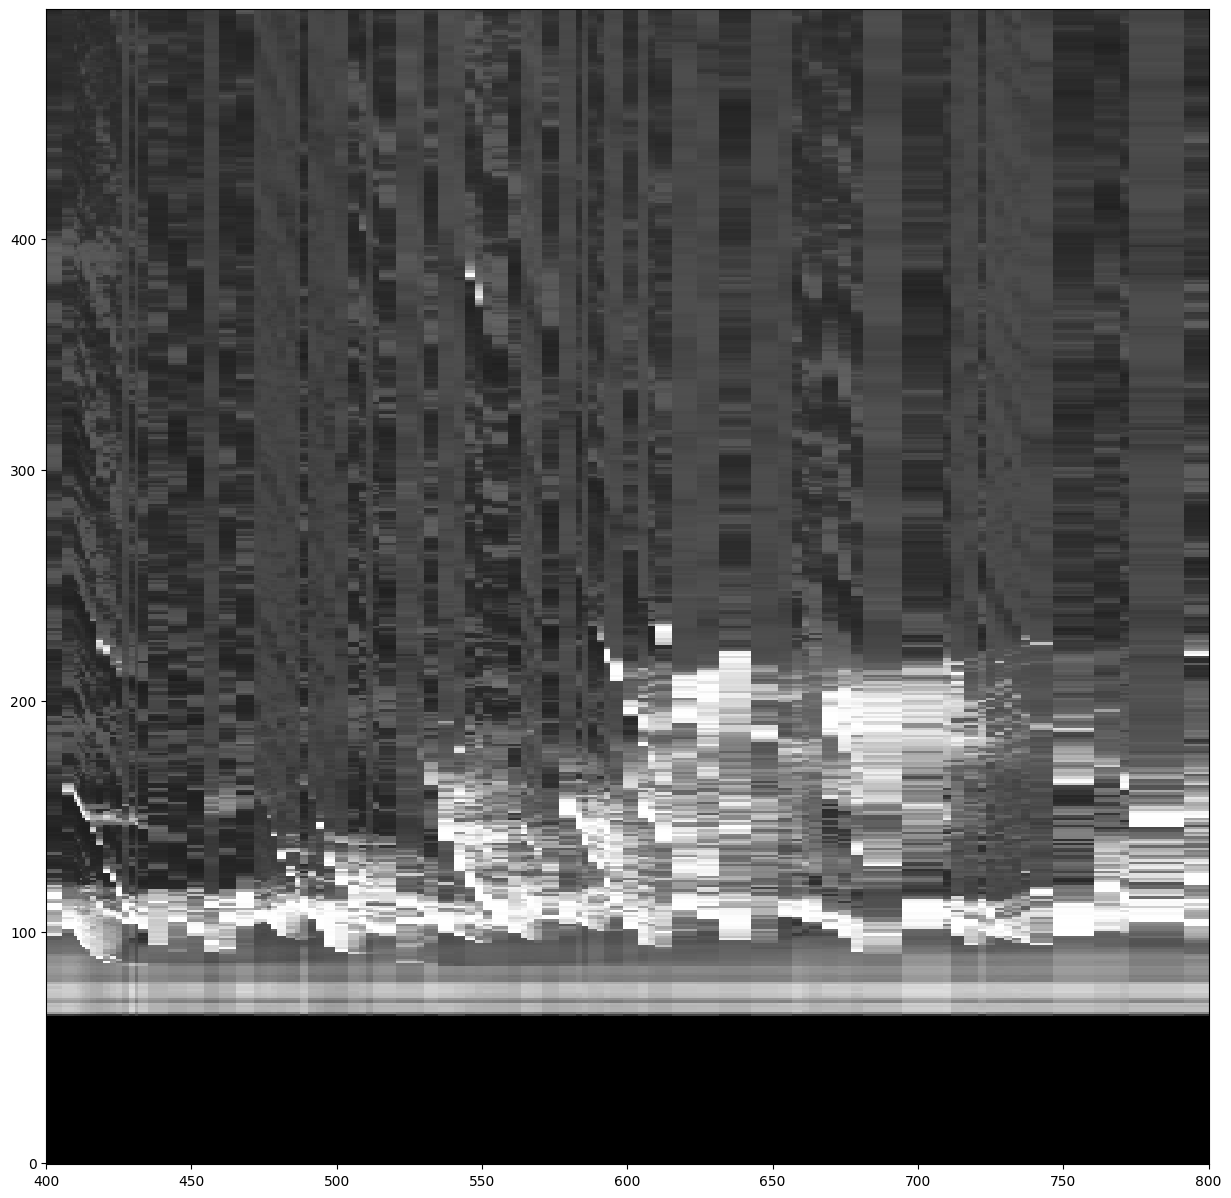

In [69]:
## Squeeze out missing data from the bottom camera
t = timestack[:, 5, :].T
mask = np.sum(np.zeros_like(t) + np.sum((t==0), axis=0)[:, np.newaxis].T > 150, axis=0)==0
plt.figure(figsize=(15, 15))
xs, ys = np.mgrid[0:t.shape[1], 0:t.shape[0]]
plt.pcolormesh(xs[mask], ys[mask], t[:, mask].T, shading='auto')
plt.xlim([400, 800])